# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename = "~/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

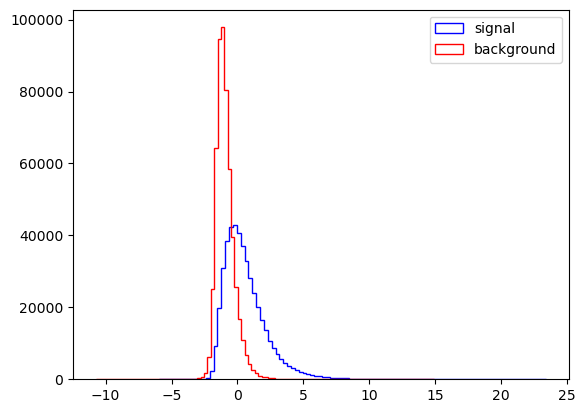

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

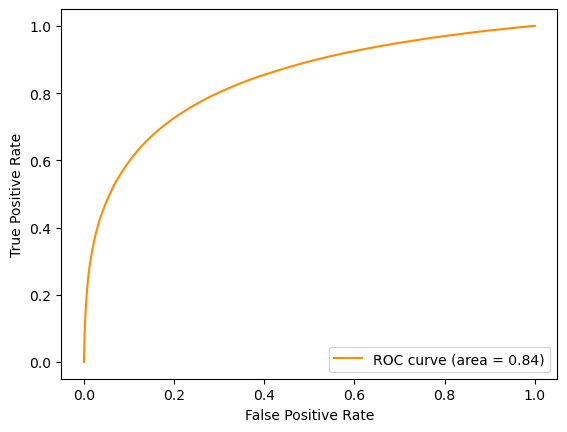

In [7]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


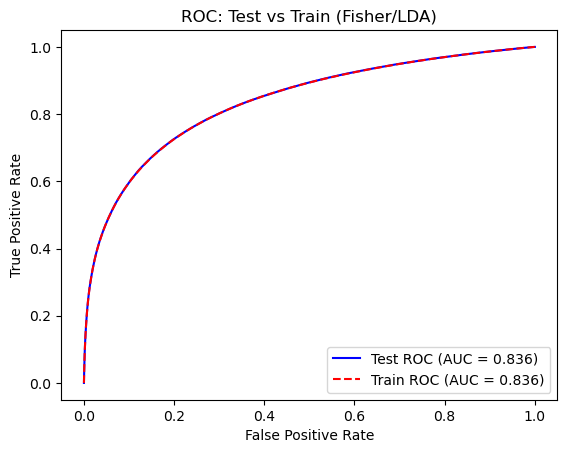

In [8]:
# 3a

from sklearn.metrics import roc_curve, auc

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', label=f'Test ROC (AUC = {auc_test:.3f})')
plt.plot(fpr_train, tpr_train, color='red', linestyle='--', label=f'Train ROC (AUC = {auc_train:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC: Test vs Train (Fisher/LDA)')
plt.legend(loc='lower right')
plt.show()
# If AUC_train ≈ AUC_test → no significant bias (LDA is low-variance, expected)

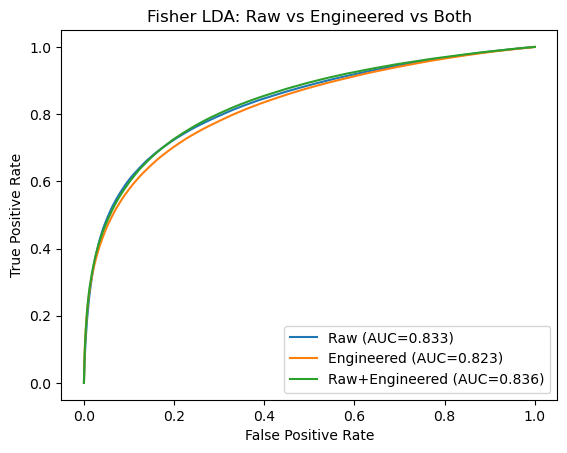

In [9]:
# 3b

raw_features = VarNames[1:9]   # low-level: lepton/MET kinematics
eng_features = VarNames[9:]    # high-level: derived/engineered
all_features = VarNames[1:]    # everything

scenarios = {
    "Raw":             raw_features,
    "Engineered":      eng_features,
    "Raw+Engineered":  all_features
}

plt.figure()
for label, feats in scenarios.items():
    clf = DA.LinearDiscriminantAnalysis()
    clf.fit(Train_Sample[feats], y_Train)
    fpr, tpr, _ = roc_curve(y_Test, clf.decision_function(Test_Sample[feats]))
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc(fpr,tpr):.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher LDA: Raw vs Engineered vs Both')
plt.legend(loc='lower right')
plt.show()

In [10]:
# 4a 

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# These are the 3 classifiers that will be used
clf1 = GaussianNB()
clf2 = LogisticRegression(max_iter=1000)
clf3 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

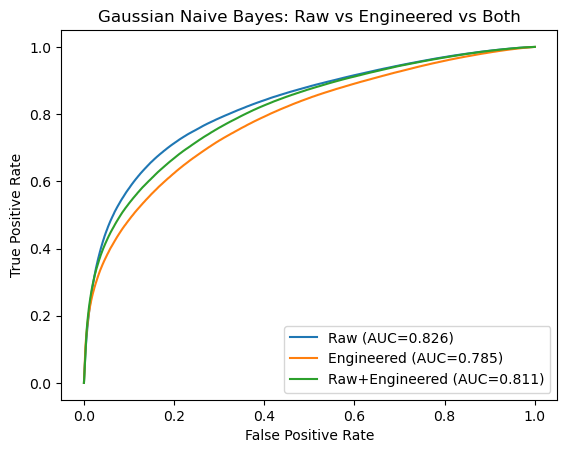

In [ ]:
# 4b

import sklearn.base

def compare_classifier(clf, clf_name):
    plt.figure()
    for label, feats in scenarios.items():
        clf_copy = sklearn.base.clone(clf)
        clf_copy.fit(Train_Sample[feats], y_Train)
        
        if hasattr(clf_copy, "decision_function"):
            scores = clf_copy.decision_function(Test_Sample[feats])
        else:
            scores = clf_copy.predict_proba(Test_Sample[feats])[:, 1]
        
        fpr, tpr, _ = roc_curve(y_Test, scores)
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc(fpr,tpr):.3f})')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{clf_name}: Raw vs Engineered vs Both')
    plt.legend(loc='lower right')
    plt.show()

# Running on all 3 classifiers
compare_classifier(clf1, "Gaussian Naive Bayes")
compare_classifier(clf2, "Logistic Regression")
compare_classifier(clf3, "Random Forest")

In [11]:
# 4c

N_small = 100000

Train_Small = df[:N_small]
Test_Small  = df[N_small:N_small+20000]

X_Train_small = Train_Small[all_features]
y_Train_small = Train_Small["signal"]

X_Test_small  = Test_Small[all_features]
y_Test_small  = Test_Small["signal"]

best_clf = RandomForestClassifier(n_estimators=5, n_jobs=-1, random_state=42)
best_clf.fit(X_Train_small, y_Train_small)

scores_test = best_clf.predict_proba(X_Test_small)[:, 1]
fpr_arr, tpr_arr, thresholds = roc_curve(y_Test_small, scores_test)

N_S = tpr_arr * (y_Test_small == 1).sum()
N_B = fpr_arr * (y_Test_small == 0).sum()

with np.errstate(invalid='ignore'):
    significance = N_S / np.sqrt(N_S + N_B)

max_idx = np.nanargmax(significance)
print(f"Max significance: {significance[max_idx]:.2f}")
print(f"At threshold:     {thresholds[max_idx]:.4f}")
print(f"TPR: {tpr_arr[max_idx]:.3f}  |  FPR: {fpr_arr[max_idx]:.3f}")

# smaller data set used as the original values led my Kernel to shut down

Max significance: 70.40
At threshold:     0.6000
TPR: 0.705  |  FPR: 0.182


In [14]:
# 5b

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tabulate import tabulate
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc
import numpy as np

results = []

for label, feats in scenarios.items():
    clf = clone(best_clf)
    clf.fit(Train_Sample[feats], y_Train)
    
    scores = clf.predict_proba(Test_Sample[feats])[:, 1]
    y_pred = clf.predict(Test_Sample[feats])
    
    fpr_a, tpr_a, thresh = roc_curve(y_Test, scores)
    roc_auc_val = auc(fpr_a, tpr_a)
    
    N_S = tpr_a * (y_Test == 1).sum()
    N_B = fpr_a * (y_Test == 0).sum()
    with np.errstate(invalid='ignore'):
        max_sig = np.nanmax(N_S / np.sqrt(N_S + N_B))
    
    fp  = ((y_pred==1) & (y_Test==0)).sum()
    tn  = ((y_pred==0) & (y_Test==0)).sum()
    fpr_val = fp / (fp + tn)
    tpr_val = recall_score(y_Test, y_pred)
    
    results.append([
        label,
        f"{tpr_val:.3f}",
        f"{fpr_val:.3f}",
        f"{roc_auc_val:.3f}",
        f"{precision_score(y_Test, y_pred):.3f}",
        f"{recall_score(y_Test, y_pred):.3f}",
        f"{f1_score(y_Test, y_pred):.3f}",
        f"{accuracy_score(y_Test, y_pred):.3f}",
        f"{max_sig:.2f}"
    ])

headers = ["Scenario", "TPR", "FPR", "AUC", "Precision", "Recall", "F1", "Accuracy", "Max Sig"]
print(tabulate(results, headers=headers, tablefmt="grid"))

# Claude helped with planning the code and debugging it

+----------------+-------+-------+-------+-------------+----------+-------+------------+-----------+
| Scenario       |   TPR |   FPR |   AUC |   Precision |   Recall |    F1 |   Accuracy |   Max Sig |
+================+=======+=======+=======+=============+==========+=======+============+===========+
| Raw            | 0.697 | 0.193 | 0.813 |       0.753 |    0.697 | 0.724 |      0.757 |    492.68 |
+----------------+-------+-------+-------+-------------+----------+-------+------------+-----------+
| Engineered     | 0.702 | 0.191 | 0.815 |       0.756 |    0.702 | 0.728 |      0.76  |    493.25 |
+----------------+-------+-------+-------+-------------+----------+-------+------------+-----------+
| Raw+Engineered | 0.711 | 0.184 | 0.826 |       0.766 |    0.711 | 0.738 |      0.768 |    499.64 |
+----------------+-------+-------+-------+-------------+----------+-------+------------+-----------+
